# Лабораторная работа №3 — Линейные классификаторы

Рассматриваются четыре классификатора:

- байесовский — как эталон для сравнения;
- классификатор Фишера;
- линейный классификатор минимума СКО решения;
- линейный классификатор на основе процедуры Роббинса–Монро.

### 1. Общий вид линейного классификатора

По методичке линейный классификатор задаётся в виде

$$
d(x)=W^T x + w_N
$$

Решение принимается так:
- если $d(x) < 0$, объект относим к $\Omega_0$;
- если $d(x) > 0$, объект относим к $\Omega_1$.

---

### 2. Байесовский классификатор

#### Случай равных ковариационных матриц

Если $B_0 = B_1 = B$ и априорные вероятности равны, то байесовская решающая функция имеет линейный вид:

$$
d_B(x)= (M_1-M_0)^T B^{-1}x - \frac12 (M_1+M_0)^T B^{-1}(M_1-M_0)
$$

---

#### Случай неравных ковариационных матриц

Если $B_0 \ne B_1$, то байесовская функция становится квадратической:

$$
d_B(x)=
-\frac12 (x-M_1)^T B_1^{-1}(x-M_1)
+\frac12 (x-M_0)^T B_0^{-1}(x-M_0)
+\frac12 \ln\frac{|B_0|}{|B_1|}
$$

---

### 3. Классификатор Фишера

#### Общий случай

$$
W = \left(\frac{B_1+B_0}{2}\right)^{-1}(M_1-M_0)
$$

$$
w_N = -\frac{\sigma_1^2\, W^T M_0 + \sigma_0^2\, W^T M_1}{\sigma_0^2+\sigma_1^2}
$$

$$
\sigma_l^2 = W^T B_l W
$$

---

#### Частный случай $B_0=B_1=B$

$$
W = B^{-1}(M_1-M_0)
$$

$$
w_N = -\frac12 (M_1-M_0)^T B^{-1}(M_0+M_1)
$$

---

### 4. Классификатор минимума СКО

$$
z=(x_1,x_2,1)^T
$$

$$
W=(w_1,w_2,w_N)^T
$$

$$
\varepsilon^2 = \frac1K \sum_{k=1}^{K}\big(\gamma(z_k)-W^T z_k\big)^2
$$

---

### 5. Роббинс–Монро

$$
W(k+1)=W(k)+\alpha_k\,x(k)\,\big(r(x(k))-W^T(k)x(k)\big)
$$

$$
\alpha_k = \frac{c}{k^\beta}, \qquad \frac12 < \beta \le 1
$$

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm

plt.rcParams["figure.figsize"] = (7, 6)
plt.rcParams["axes.grid"] = True
seed = 42

## 1. Загрузка готовых данных из лабораторных работ 1 и 2

In [21]:
from pathlib import Path
import numpy as np
import pandas as pd

base_dir = Path('.')

N = 200
M0 = np.array([-1.0,  1.0], dtype=float)   # Ω0
M1 = np.array([ 0.0, -1.0], dtype=float)   # Ω1

B_equal = np.array([
    [0.16 , 0.032],
    [0.032, 0.16 ]
], dtype=float)

B0_neq = np.array([
    [0.04, 0.08],
    [0.08, 0.64]
], dtype=float)

B1_neq = np.array([
    [ 0.49  , -0.105 ],
    [-0.105 ,  0.0625]
], dtype=float)

eq0_path = base_dir / "gauss_step2_class1.npy"
eq1_path = base_dir / "gauss_step2_class2.npy"
neq0_path = base_dir / "gauss_step3_class1.npy"
neq1_path = base_dir / "gauss_step3_class2.npy"

required_files = [eq0_path, eq1_path, neq0_path, neq1_path]
missing = [str(p) for p in required_files if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Не найдены нужные .npy файлы из lab_1/lab_2: "
        + ", ".join(missing)
        + ". Сначала нужно, чтобы рядом с этим ноутбуком лежали сохранённые файлы из ЛР1."
    )

Xeq0 = np.load(eq0_path)
Xeq1 = np.load(eq1_path)
Xneq0 = np.load(neq0_path)
Xneq1 = np.load(neq1_path)

display(pd.DataFrame({
    "Набор": ["Xeq0", "Xeq1", "Xneq0", "Xneq1"],
    "Форма": [Xeq0.shape, Xeq1.shape, Xneq0.shape, Xneq1.shape],
    "Источник": [
        "gauss_step2_class1.npy",
        "gauss_step2_class2.npy",
        "gauss_step3_class1.npy",
        "gauss_step3_class2.npy",
    ]
}))

display(pd.DataFrame({
    "Параметр": ["M0", "M1"],
    "Значение": [M0, M1]
}))
print("B_equal =\n", B_equal)
print("\nB0_neq =\n", B0_neq)
print("\nB1_neq =\n", B1_neq)

,Набор,Форма,Источник
0,Xeq0,"(200, 2)",gauss_step2_class1.npy
1,Xeq1,"(200, 2)",gauss_step2_class2.npy
2,Xneq0,"(200, 2)",gauss_step3_class1.npy
3,Xneq1,"(200, 2)",gauss_step3_class2.npy


,Параметр,Значение
0,M0,"[-1.0, 1.0]"
1,M1,"[0.0, -1.0]"


B_equal =
 [[0.16  0.032]
 [0.032 0.16 ]]

B0_neq =
 [[0.04 0.08]
 [0.08 0.64]]

B1_neq =
 [[ 0.49   -0.105 ]
 [-0.105   0.0625]]


In [22]:
def mle_estimates(X):
    M_hat = X.mean(axis=0)
    Xc = X - M_hat
    B_hat = (Xc.T @ Xc) / len(X)
    return M_hat, B_hat

M0_eq_hat, B0_eq_hat = mle_estimates(Xeq0)
M1_eq_hat, B1_eq_hat = mle_estimates(Xeq1)
M0_neq_hat, B0_neq_hat = mle_estimates(Xneq0)
M1_neq_hat, B1_neq_hat = mle_estimates(Xneq1)

display(pd.DataFrame({
    "Случай": ["equal Ω0", "equal Ω1", "unequal Ω0", "unequal Ω1"],
    "M_hat": [M0_eq_hat, M1_eq_hat, M0_neq_hat, M1_neq_hat],
    "B_hat": [B0_eq_hat, B1_eq_hat, B0_neq_hat, B1_neq_hat],
}))

,Случай,M_hat,B_hat
0,equal Ω0,"[-0.9695010782677727, 0.9870804488554521]","[[0.18224283613217934, 0.021871573875954682], ..."
1,equal Ω1,"[0.029054091543276178, -1.0240682801691465]","[[0.17948299302614146, 0.05515007293753369], [..."
2,unequal Ω0,"[-1.020197619338839, 1.02809577071222]","[[0.03969704082710849, 0.08569191468925133], [..."
3,unequal Ω1,"[-0.024638586596429077, -0.9869251412226993]","[[0.5325198558343038, -0.09907295192576608], [..."


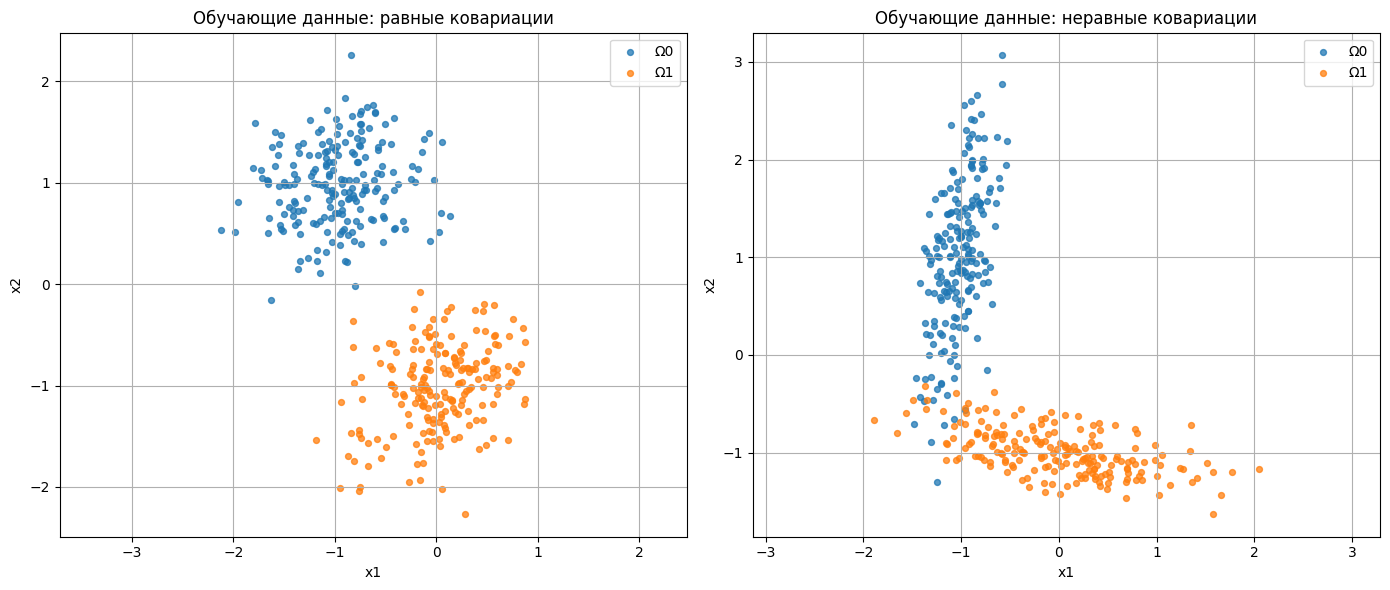

In [23]:

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(Xeq0[:, 0], Xeq0[:, 1], s=18, alpha=0.75, label='Ω0')
axes[0].scatter(Xeq1[:, 0], Xeq1[:, 1], s=18, alpha=0.75, label='Ω1')
axes[0].set_title("Обучающие данные: равные ковариации")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")
axes[0].axis("equal")
axes[0].legend()

axes[1].scatter(Xneq0[:, 0], Xneq0[:, 1], s=18, alpha=0.75, label='Ω0')
axes[1].scatter(Xneq1[:, 0], Xneq1[:, 1], s=18, alpha=0.75, label='Ω1')
axes[1].set_title("Обучающие данные: неравные ковариации")
axes[1].set_xlabel("x1")
axes[1].set_ylabel("x2")
axes[1].axis("equal")
axes[1].legend()

plt.tight_layout()
plt.show()


## 2. Вспомогательные функции

In [24]:
def gaussian_discriminant(X, M, B, prior=0.5):
    X = np.atleast_2d(X)
    diff = X - M
    B_inv = np.linalg.inv(B)
    sign, logdet = np.linalg.slogdet(B)
    quad = np.sum((diff @ B_inv) * diff, axis=1)
    return np.log(prior) - 0.5 * logdet - 0.5 * quad

def bayes_score_equal_cov(X, M0, M1, B, P0=0.5, P1=0.5):
    X = np.atleast_2d(X)
    B_inv = np.linalg.inv(B)
    a = B_inv @ (M1 - M0)
    b = -0.5 * (M1 + M0).T @ B_inv @ (M1 - M0) + np.log(P1 / P0)
    return X @ a + b

def bayes_score_general(X, M0, B0, M1, B1, P0=0.5, P1=0.5):
    return gaussian_discriminant(X, M1, B1, prior=P1) - gaussian_discriminant(X, M0, B0, prior=P0)

def augmented_data(X0, X1):
    Z0 = np.hstack([X0, np.ones((len(X0), 1))])
    Z1 = np.hstack([X1, np.ones((len(X1), 1))])
    Z = np.vstack([Z0, Z1])
    y = np.hstack([-np.ones(len(X0)), np.ones(len(X1))])
    return Z, y

def linear_score(X, W):
    X = np.atleast_2d(X)
    return X @ W[:2] + W[2]

def experimental_errors(X0, X1, score_func):
    s0 = np.ravel(score_func(X0))
    s1 = np.ravel(score_func(X1))
    p0_err = np.mean(s0 > 0)
    p1_err = np.mean(s1 <= 0)
    p_sum = 0.5 * (p0_err + p1_err)
    return p0_err, p1_err, p_sum

def plot_boundary(ax, score_func, X0, X1, title):
    allX = np.vstack([X0, X1])
    x_min, x_max = allX[:, 0].min() - 1.0, allX[:, 0].max() + 1.0
    y_min, y_max = allX[:, 1].min() - 1.0, allX[:, 1].max() + 1.0
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )
    grid = np.column_stack([xx.ravel(), yy.ravel()])
    zz = np.ravel(score_func(grid)).reshape(xx.shape)

    ax.scatter(X0[:, 0], X0[:, 1], s=18, alpha=0.75, label='Ω0')
    ax.scatter(X1[:, 0], X1[:, 1], s=18, alpha=0.75, label='Ω1')
    ax.contour(xx, yy, zz, levels=[0], colors='black', linewidths=2)
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.axis("equal")
    ax.grid(True)

## 2. Байесовский классификатор
Сначала строим эталонные байесовские границы: линейную для случая равных ковариаций и квадратическую для случая неравных ковариаций. Далее все линейные методы сравниваются именно с этими границами.

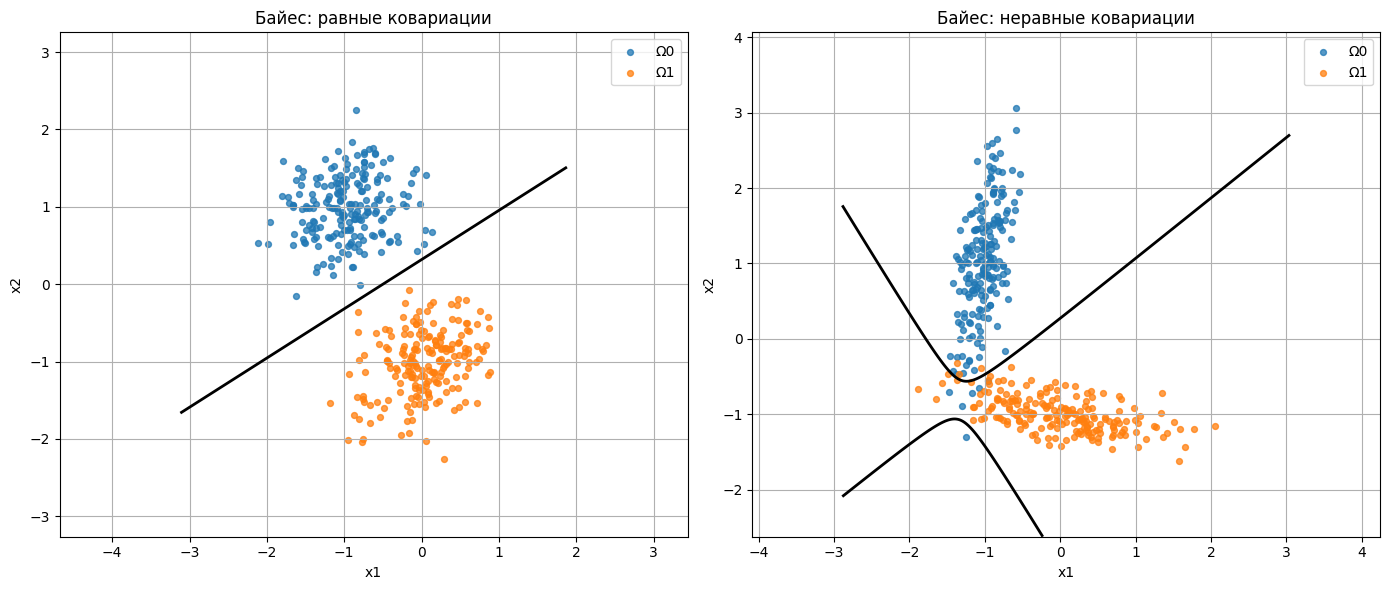

In [25]:

score_bayes_eq = lambda X: bayes_score_equal_cov(X, M0, M1, B_equal)
score_bayes_neq = lambda X: bayes_score_general(X, M0, B0_neq, M1, B1_neq)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_boundary(axes[0], score_bayes_eq, Xeq0, Xeq1, "Байес: равные ковариации")
plot_boundary(axes[1], score_bayes_neq, Xneq0, Xneq1, "Байес: неравные ковариации")
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()


## 3. Классификатор Фишера
Здесь реализуется формула методички. Для равных ковариаций он должен совпасть с байесовским классификатором; для неравных — дать лучшую линейную аппроксимацию по критерию Фишера.

In [26]:

def fisher_weights_general(M0, B0, M1, B1):
    S = 0.5 * (B0 + B1)
    W = np.linalg.inv(S) @ (M1 - M0)
    sigma0_sq = float(W.T @ B0 @ W)
    sigma1_sq = float(W.T @ B1 @ W)
    wN = -((sigma1_sq * (W @ M0)) + (sigma0_sq * (W @ M1))) / (sigma0_sq + sigma1_sq)
    return np.array([W[0], W[1], wN], dtype=float), sigma0_sq, sigma1_sq

def fisher_weights_equal(M0, M1, B):
    W = np.linalg.inv(B) @ (M1 - M0)
    wN = -0.5 * ((M1 - M0).T @ np.linalg.inv(B) @ (M0 + M1))
    return np.array([W[0], W[1], float(wN)], dtype=float)

W_fisher_eq = fisher_weights_equal(M0, M1, B_equal)
W_fisher_neq, sig0_f, sig1_f = fisher_weights_general(M0, B0_neq, M1, B1_neq)

print("W_fisher_eq =", W_fisher_eq)
print("W_fisher_neq =", W_fisher_neq)
print("σ0², σ1² (неравные B) =", sig0_f, sig1_f)


W_fisher_eq = [  9.11458333 -14.32291667   4.55729167]
W_fisher_neq = [ 3.51089588 -5.56900726  0.47312231]
σ0², σ1² (неравные B) = 17.213561667125912 12.084259156118637


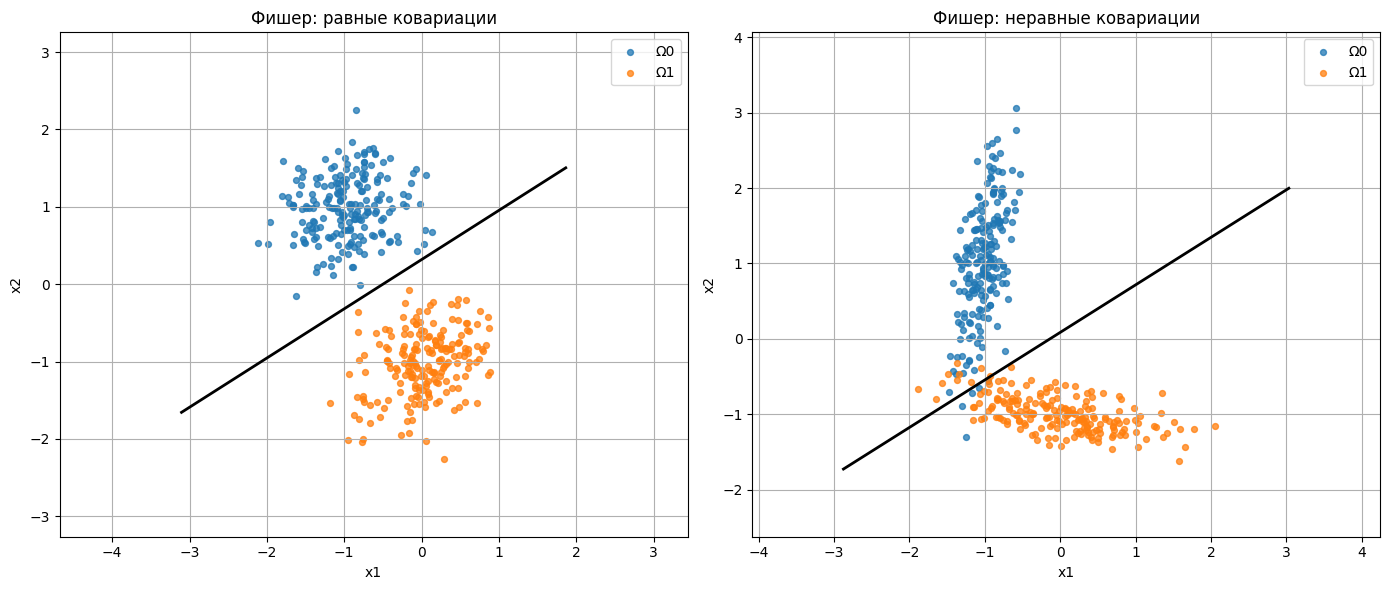

In [27]:

score_fisher_eq = lambda X: linear_score(X, W_fisher_eq)
score_fisher_neq = lambda X: linear_score(X, W_fisher_neq)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_boundary(axes[0], score_fisher_eq, Xeq0, Xeq1, "Фишер: равные ковариации")
plot_boundary(axes[1], score_fisher_neq, Xneq0, Xneq1, "Фишер: неравные ковариации")
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()


## 4. Проверка совпадения Байеса и Фишера при равных ковариациях

In [28]:

print("Разность между коэффициентами Байеса и Фишера (равные B) практически нулевая:")
B_inv = np.linalg.inv(B_equal)
W_bayes_eq = np.array([
    *(B_inv @ (M1 - M0)),
    -0.5 * ((M1 + M0).T @ B_inv @ (M1 - M0))
], dtype=float)

print("W_bayes_eq  =", W_bayes_eq)
print("W_fisher_eq =", W_fisher_eq)
print("max abs diff =", np.max(np.abs(W_bayes_eq - W_fisher_eq)))


Разность между коэффициентами Байеса и Фишера (равные B) практически нулевая:
W_bayes_eq  = [  9.11458333 -14.32291667   4.55729167]
W_fisher_eq = [  9.11458333 -14.32291667   4.55729167]
max abs diff = 0.0


## 5. Линейный классификатор минимума СКО
Переходим к пополненным векторам признаков и решаем задачу наименьших квадратов. Получается линейная граница, которая минимизирует среднеквадратичное отклонение решения от целевых меток.

In [29]:

def mse_classifier(X0, X1, target_abs=1.0):
    Z, y = augmented_data(X0, X1)
    gamma = target_abs * y
    W, *_ = np.linalg.lstsq(Z, gamma, rcond=None)
    return W

W_mse_eq = mse_classifier(Xeq0, Xeq1, target_abs=1.0)
W_mse_neq = mse_classifier(Xneq0, Xneq1, target_abs=1.0)

print("W_mse_eq  =", W_mse_eq)
print("W_mse_neq =", W_mse_neq)


W_mse_eq  = [ 0.42245687 -0.68506442  0.18597962]
W_mse_neq = [ 0.34696479 -0.61497875  0.19392022]


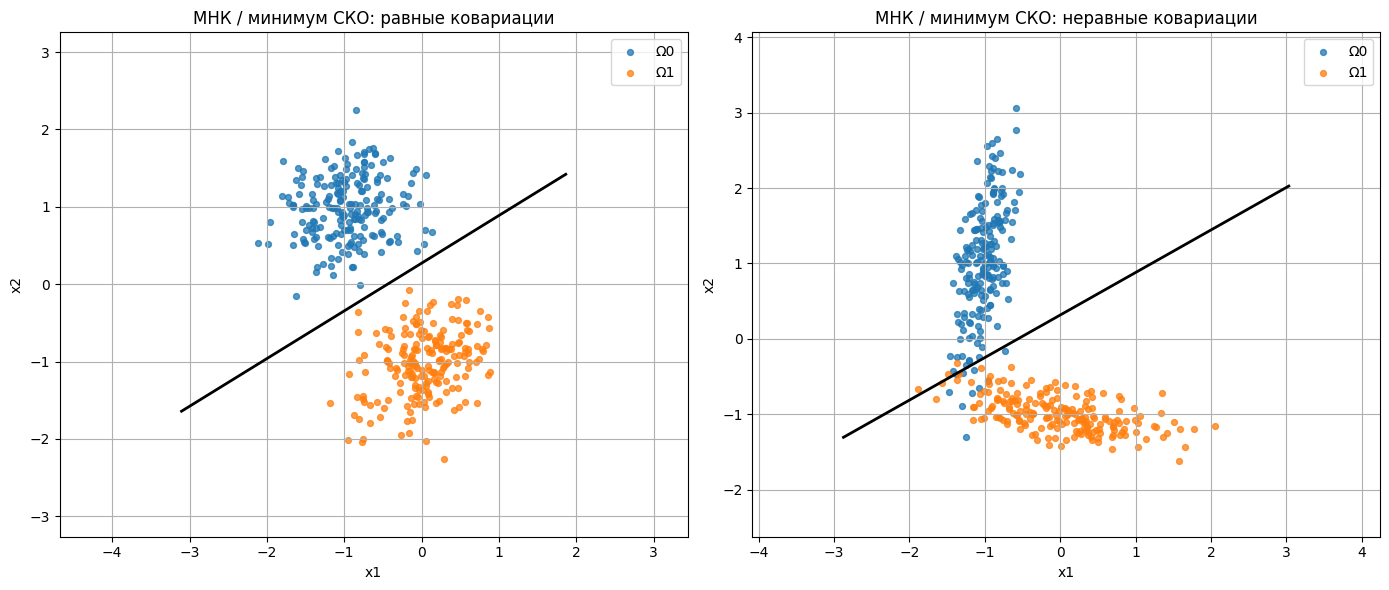

In [30]:

score_mse_eq = lambda X: linear_score(X, W_mse_eq)
score_mse_neq = lambda X: linear_score(X, W_mse_neq)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_boundary(axes[0], score_mse_eq, Xeq0, Xeq1, "МНК / минимум СКО: равные ковариации")
plot_boundary(axes[1], score_mse_neq, Xneq0, Xneq1, "МНК / минимум СКО: неравные ковариации")
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()


## 6. Роббинс–Монро
Здесь реализован НСКО-вариант стохастической аппроксимации. На каждом шаге берётся один объект, вычисляется ошибка \(r - W^T z\), после чего веса корректируются на величину \(lpha_k z (r - W^T z)\).

In [31]:

def robbins_monro_nsko(X0, X1, W0=None, c=1.0, beta=1.0, epochs=40, shuffle=True, use_perceptron_trick=False):
    Z, y = augmented_data(X0, X1)
    n_features = Z.shape[1]
    if W0 is None:
        W = np.zeros(n_features, dtype=float)
    else:
        W = np.array(W0, dtype=float).copy()

    hist_W = [W.copy()]
    hist_mis = []
    hist_mse = []

    k_global = 1
    for epoch in range(epochs):
        idx = np.arange(len(Z))
        if shuffle:
            np.random.default_rng(seed + epoch).shuffle(idx)

        for i in idx:
            z = Z[i]
            r = y[i]
            err = r - W @ z
            if (not use_perceptron_trick) or ((W @ z) * r <= 0):
                alpha = c / (k_global ** beta)
                W = W + alpha * err * z
                hist_W.append(W.copy())
            k_global += 1

        scores = Z @ W
        mis = np.mean(np.sign(scores) != y)
        mse = np.mean((y - scores) ** 2)
        hist_mis.append(mis)
        hist_mse.append(mse)

    return W, np.array(hist_W), np.array(hist_mis), np.array(hist_mse)

W_rm_eq, W_hist_eq, mis_hist_eq, mse_hist_eq = robbins_monro_nsko(
    Xeq0, Xeq1, W0=np.zeros(3), c=1.0, beta=1.0, epochs=40, use_perceptron_trick=False
)

W_rm_neq, W_hist_neq, mis_hist_neq, mse_hist_neq = robbins_monro_nsko(
    Xneq0, Xneq1, W0=np.zeros(3), c=1.0, beta=1.0, epochs=40, use_perceptron_trick=False
)

print("W_rm_eq  =", W_rm_eq)
print("W_rm_neq =", W_rm_neq)


W_rm_eq  = [ 0.46840089 -0.66390903  0.21248439]
W_rm_neq = [ 0.27807222 -0.64579007  0.14815182]


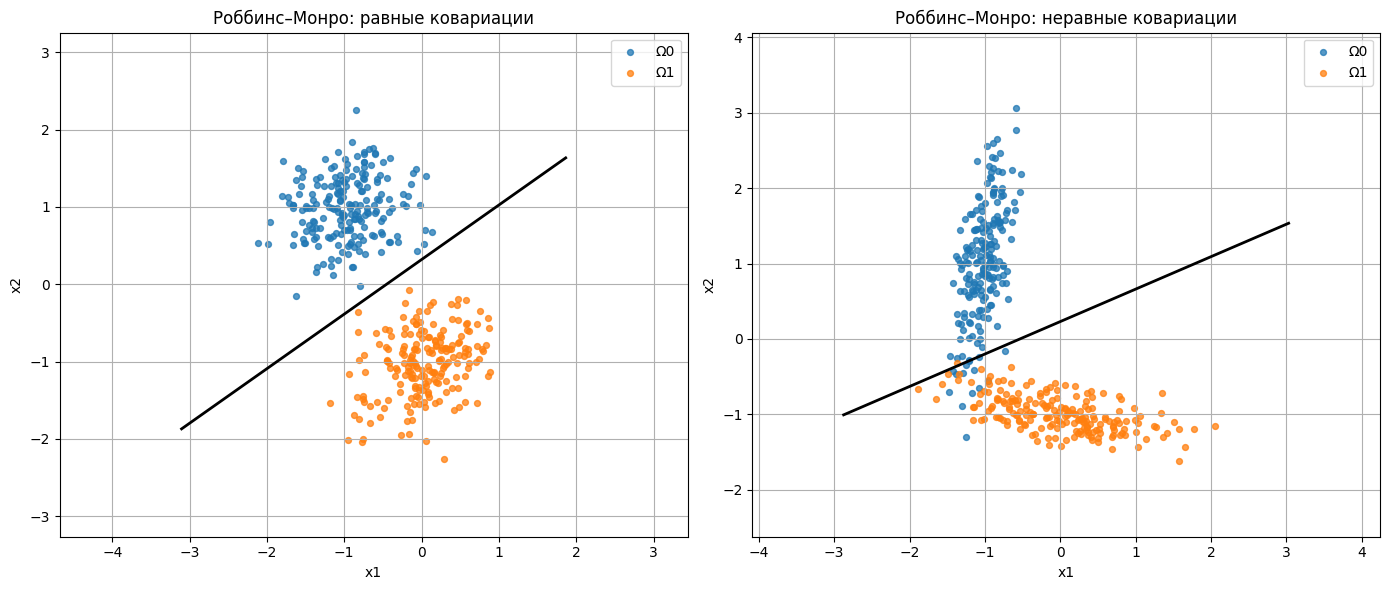

In [32]:

score_rm_eq = lambda X: linear_score(X, W_rm_eq)
score_rm_neq = lambda X: linear_score(X, W_rm_neq)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_boundary(axes[0], score_rm_eq, Xeq0, Xeq1, "Роббинс–Монро: равные ковариации")
plot_boundary(axes[1], score_rm_neq, Xneq0, Xneq1, "Роббинс–Монро: неравные ковариации")
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()


## 7. Исследование сходимости Роббинса–Монро
Проверяем, как на скорость сходимости и итоговое качество влияют начальные условия, показатель β в последовательности шагов и использование перцептронного приёма.

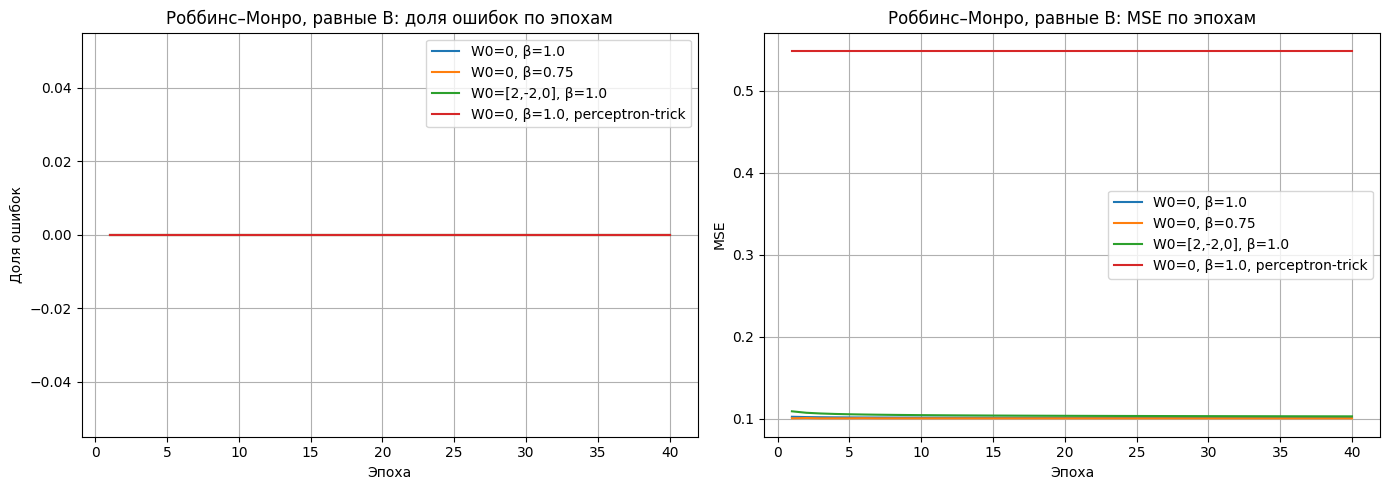

,Конфигурация,Итоговый W,Итог. доля ошибок на train,Итог. MSE на train
0,"W0=0, β=1.0","[0.4684, -0.6639, 0.2125]",0.0,0.1007
1,"W0=0, β=0.75","[0.4217, -0.6844, 0.187]",0.0,0.1002
2,"W0=[2,-2,0], β=1.0","[0.5188, -0.6407, 0.2416]",0.0,0.1026
3,"W0=0, β=1.0, perceptron-trick","[0.9086, -1.0684, 0.4037]",0.0,0.5484


In [33]:

def compare_rm_configs(X0, X1, title_prefix):
    configs = [
        ("W0=0, β=1.0", np.zeros(3), 1.0, 1.0, False),
        ("W0=0, β=0.75", np.zeros(3), 1.0, 0.75, False),
        ("W0=[2,-2,0], β=1.0", np.array([2.0, -2.0, 0.0]), 1.0, 1.0, False),
        ("W0=0, β=1.0, perceptron-trick", np.zeros(3), 1.0, 1.0, True),
    ]

    rows = []
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for name, W0, c, beta, trick in configs:
        W, Wh, mis_h, mse_h = robbins_monro_nsko(
            X0, X1, W0=W0, c=c, beta=beta, epochs=40, use_perceptron_trick=trick
        )
        axes[0].plot(np.arange(1, len(mis_h)+1), mis_h, label=name)
        axes[1].plot(np.arange(1, len(mse_h)+1), mse_h, label=name)
        rows.append({
            "Конфигурация": name,
            "Итоговый W": np.round(W, 4),
            "Итог. доля ошибок на train": float(np.round(mis_h[-1], 4)),
            "Итог. MSE на train": float(np.round(mse_h[-1], 4)),
        })

    axes[0].set_title(f"{title_prefix}: доля ошибок по эпохам")
    axes[0].set_xlabel("Эпоха")
    axes[0].set_ylabel("Доля ошибок")

    axes[1].set_title(f"{title_prefix}: MSE по эпохам")
    axes[1].set_xlabel("Эпоха")
    axes[1].set_ylabel("MSE")

    axes[0].legend()
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    return pd.DataFrame(rows)

rm_eq_table = compare_rm_configs(Xeq0, Xeq1, "Роббинс–Монро, равные B")
rm_eq_table


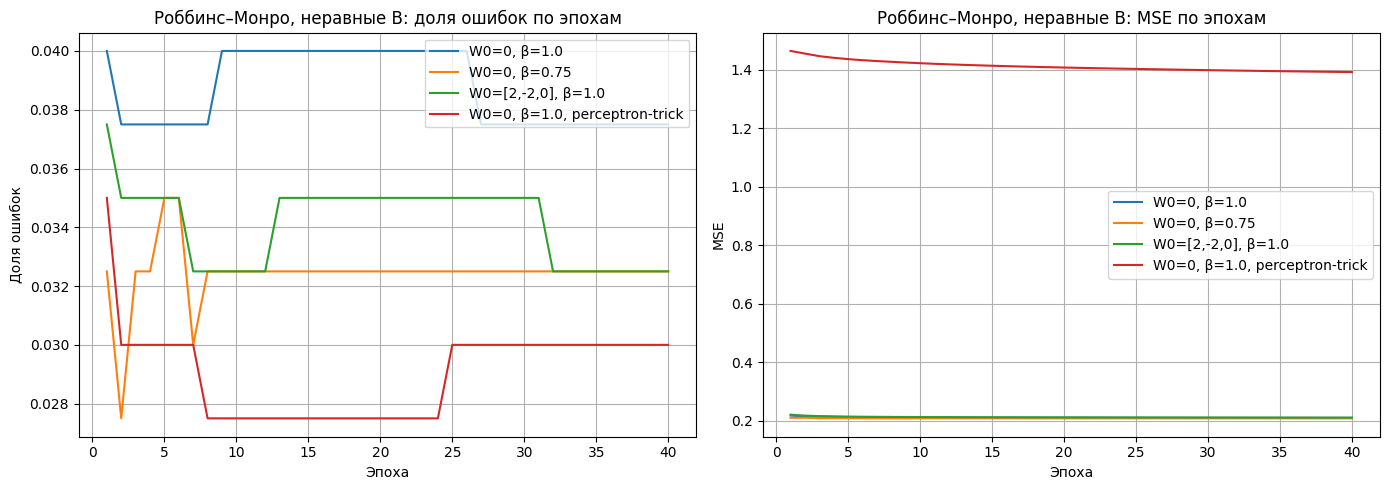

,Конфигурация,Итоговый W,Итог. доля ошибок на train,Итог. MSE на train
0,"W0=0, β=1.0","[0.2781, -0.6458, 0.1482]",0.0375,0.2095
1,"W0=0, β=0.75","[0.3456, -0.614, 0.195]",0.0325,0.2077
2,"W0=[2,-2,0], β=1.0","[0.4265, -0.5792, 0.2466]",0.0325,0.2100
3,"W0=0, β=1.0, perceptron-trick","[0.7725, -1.359, 0.3003]",0.0300,1.3915


In [34]:
rm_neq_table = compare_rm_configs(Xneq0, Xneq1, "Роббинс–Монро, неравные B")
rm_neq_table


## 8. Экспериментальные вероятности ошибок
Теперь для каждого метода считаем экспериментальные вероятности ошибок на тех самых готовых выборках из ЛР1.

In [35]:
def eval_all_case(case_name, X0, X1, scorers):
    rows = []
    for method_name, score_func in scorers.items():
        p0, p1, ps = experimental_errors(X0, X1, score_func)
        rows.append({
            "Случай": case_name,
            "Метод": method_name,
            "p0": p0,
            "p1": p1,
            "pΣ": ps,
        })
    return pd.DataFrame(rows)

df_eq = eval_all_case(
    "Равные B",
    Xeq0, Xeq1,
    {
        "Байес": score_bayes_eq,
        "Фишер": score_fisher_eq,
        "Минимум СКО": score_mse_eq,
        "Роббинс–Монро": score_rm_eq,
    }
)

df_neq = eval_all_case(
    "Неравные B",
    Xneq0, Xneq1,
    {
        "Байес": score_bayes_neq,
        "Фишер": score_fisher_neq,
        "Минимум СКО": score_mse_neq,
        "Роббинс–Монро": score_rm_neq,
    }
)

results = pd.concat([df_eq, df_neq], ignore_index=True)
results_rounded = results.copy()
for col in ["p0", "p1", "pΣ"]:
    results_rounded[col] = results_rounded[col].map(lambda x: round(float(x), 5))
results_rounded

,Случай,Метод,p0,p1,pΣ
0,Равные B,Байес,0.000,0.000,0.0000
1,Равные B,Фишер,0.000,0.000,0.0000
2,Равные B,Минимум СКО,0.000,0.000,0.0000
3,Равные B,Роббинс–Монро,0.000,0.000,0.0000
4,Неравные B,Байес,0.025,0.015,0.0200
5,Неравные B,Фишер,0.025,0.050,0.0375
6,Неравные B,Минимум СКО,0.050,0.015,0.0325
7,Неравные B,Роббинс–Монро,0.070,0.005,0.0375
